Defaulting to user installation because normal site-packages is not writeable


NOTE ON PARAMETER SCALING


- When we generated 500 parameter sets, the code automatically saved the latent vectors used and their corresponding maximum eigenvalues.
- These eigenvalues were computed after batch-scaling all 500 parameter sets together, so that the resulting Km values fit within physiological ranges taken from BRENDA. <br>


- For the latent-space perturbation analysis, every perturbed parameter set must be compared to its baseline.
- To do this correctly, the perturbed parameter sets must be scaled together with the original 500 samples.
- Scaling only the ~99 perturbed samples would distort the range, because this smaller set does not represent the full Km distribution.<br>


- As a result, the baseline eigenvalue used in latent-space analysis may differ slightly from the original eigenvalue stored during sampling.
- This difference comes from re-scaling the original sample together with the perturbed samples, which changes the scaling bounds.<br>

Incidence Generator 40: 5.00%
Incidence Generator 62: 15.00%
Incidence Generator 94: 23.00%


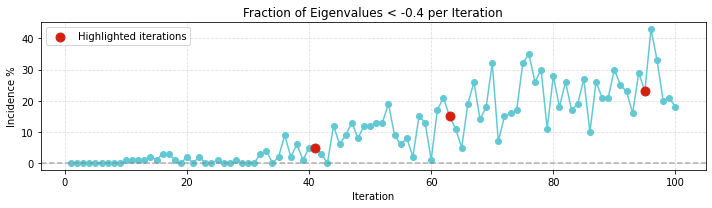

In [22]:
import pandas as pd
import numpy as np
df = pd.read_csv("latent_analysis/output/km-18to2_decay99/training/eigenvalue_log.csv")


incidences = helpersLatent.get_incidence_at_training(df)
highlight_iters = [40, 62, 94]
fig = helpersLatent.plot_training_incidence(incidences, highlight_iters)

fig_name = "TRAINING_generator.svg"
fig_path = 'latent_analysis/output/km-18to2_decay99/plots/final/' + fig_name
fig.savefig(
    fig_path,
    bbox_inches="tight"
)

# Running the analysis

To run the latent analysis, execute:
`run latent_analysis/5-latent_analysis.py`<br>

All settings are controlled in:
`latent_analysis/latent_config.ini`

The script supports three tasks:


- Individual feature perturbation


- Joint perturbation of two selected features


- A full pipeline that runs both analyses on three representative latent points



# Max Eigenvalue Distribution of sampeled models (prior distribution)

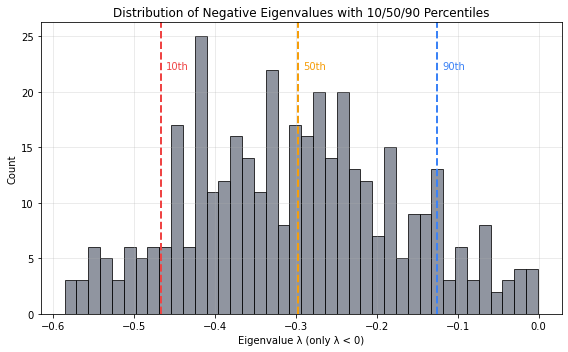

In [14]:

it = 62
path = (
    f"latent_analysis/output/km-18to2_decay99/sampling/iter{it}/samples/"
    "500_sampled_params_max_eig.csv"
)
colors = {
    "hist": "#6B7280",   # slate gray
    10: "#EF4444",       # soft red
    50: "#F59E0B",       # amber
    90: "#3B82F6",       # soft blue
}


fig, percentiles = helperLatent.plot_negative_eigenvalue_distribution(path, colors = colors, offset = -0.035)

fig.savefig(
    f"latent_analysis/output/km-18to2_decay99/plots/final"
    f"EIG_DIST_iter{it}.svg",
    bbox_inches="tight"
)

plt.show()


# Get 3 points clostest to 10th, 50th and 90th percentile


We select three latent-space seeds by choosing parameter sets whose maximum eigenvalues fall at the 10th, 50th, and 90th percentiles of the stable (negative) eigenvalue distribution.

In [16]:
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent
iters = [94, 62, 40]

for it in iters:

    if it == 94:
        csv_has_header=True
    else: 
        csv_has_header=False
    max_eigenvalues_path = f"latent_analysis/output/km-18to2_decay99/sampling/iter{it}/samples/500_sampled_params_max_eig.csv"
    result = helperLatent.get_3_percentile_latent_vectors_info(
        max_eigenvalues_path,
        csv_has_header=csv_has_header,    # important! You might need to set this to True depending on your CSV file
        threshold=0
    )
    print(f"iter{it} → {result}")

iter94 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.668419             341            -0.667219
1          50     -0.364737             495            -0.364933
2          90     -0.106993             167            -0.107182
iter62 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.467134             213            -0.466911
1          50     -0.297646             147            -0.296835
2          90     -0.125197             397            -0.125942
iter40 →    percentile  target_value  selected_index  selected_eigenvalue
0          10     -0.363434             496            -0.363434
1          50     -0.211659             407            -0.211659
2          90     -0.063172             288            -0.063172


In [35]:
import numpy as np
import pandas as pd

it = 62
max_eigenvalues_path = (
    f"latent_analysis/output/km-18to2_decay99/sampling/iter{it}/samples/"
    "500_sampled_params_max_eig.csv"
)

df = pd.read_csv(max_eigenvalues_path, header=None)

# Extract eigenvalues
try:
    eig = df.iloc[:, 1].values
except:
    eig = df.iloc[:, 0].values

# Keep only λ < 0
eig_neg = eig[eig < 0]

# --- 90th percentile value ---
p90 = np.percentile(eig_neg, 90)

# --- distances to p90 ---
dist = np.abs(eig_neg - p90)

# --- indices sorted by closeness ---
sorted_idx = np.argsort(dist)

# Closest and second closest
closest_idx = sorted_idx[0]
second_closest_idx = sorted_idx[2]

closest_value = eig_neg[closest_idx]
second_closest_value = eig_neg[second_closest_idx]

print(f"90th percentile value: {p90:.6f}")
print(f"Closest value:        {closest_value:.6f}")
print(f"Second closest value: {second_closest_value:.6f}")

neg_indices = np.where(eig < 0)[0]

second_closest_original_index = neg_indices[second_closest_idx]

print(f"Original CSV index: {second_closest_original_index}")



90th percentile value: -0.125197
Closest value:        -0.125942
Second closest value: -0.126796
Original CSV index: 191


# Reporting Results

In [ ]:
root = 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6'
data = helperLatent.parse_generators(root)
data

defaultdict(<function docker.work.latent_analysis.helpers.helpers_latent.parse_generators.<locals>.tree()>,
            {'gen62': defaultdict(<function docker.work.latent_analysis.helpers.helpers_latent.parse_generators.<locals>.tree()>,
                         {'single': defaultdict(<function docker.work.latent_analysis.helpers.helpers_latent.parse_generators.<locals>.tree()>,
                                      {'366_three_point_analysis': 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6/gen62/gen62_seed366_three_point_analysis.npy',
                                       '265_three_point_analysis': 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6/gen62/gen62_seed265_three_point_analysis.npy',
                                       '27_three_point_analysis': 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6/gen62/gen62_seed27_three_point_analysis.npy'})}),
             'gen40': defaultdict(<function docker.work.latent_analysis.helpers.he

# Carpet Plot

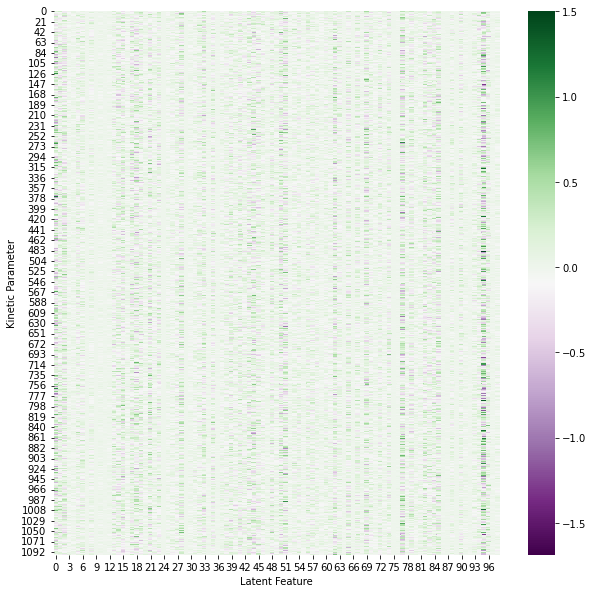

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

idx = 296
root = f"latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/latent_single_perturb_sample_{idx}_sampleIdx{idx}.npy"

params = helperLatent.results_loader(root)

baseline_params = params['pert_+1.00']['baseline_params']
perturbed_params = params['pert_+1.00']['scaled_samples']
params = np.array(perturbed_params)

pc_change_kms = []
for this_set in range(99):
    perturbed_km = (params[this_set] - baseline_params)
    pc_change_kms.append(perturbed_km)

plt.figure(figsize = (10,10))
sns.heatmap(np.transpose(pc_change_kms), cmap = 'PRGn')
plt.ylabel('Kinetic Parameter')
plt.xlabel('Latent Feature')

#plt.savefig("carpetplot_generator_95_idx_296.png", dpi = 600)

# Plotting individual and joint perturbation for a point

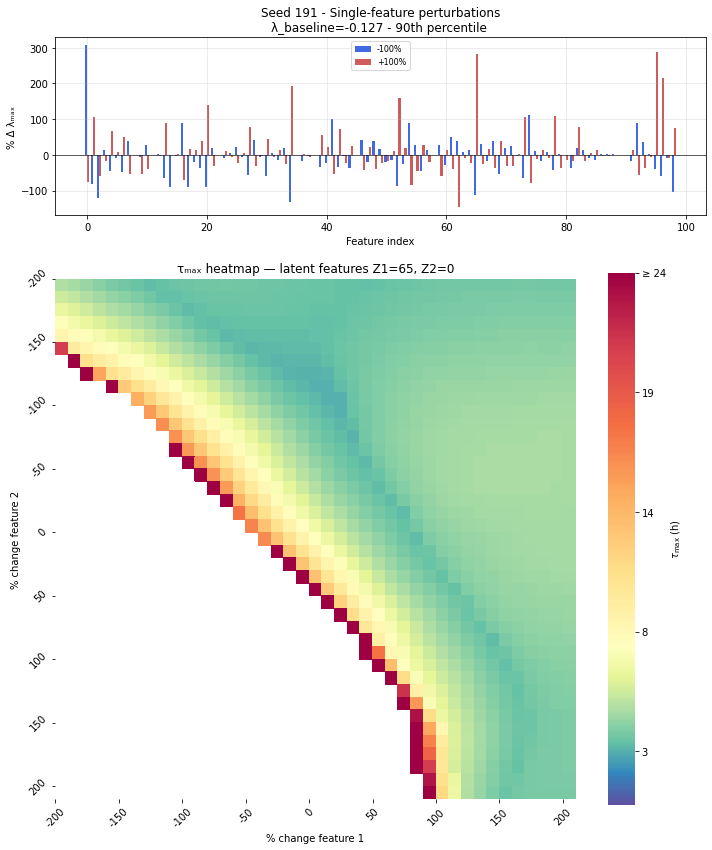

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent

root = 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6'
path_dict = helperLatent.parse_generators(root)

# generator_ids = [40, 62, 94]
   
#seed_latent_vectors = [

#        [496, 407, 288], # 40s
#        [366, 265, 27],  # 62
#        [341, 495, 167], # 94


gen_id = 62
point_id = 191
pct = 90
tau_cutoff = 24

plot = helperLatent.plot_one_point(path_dict, gen_id=gen_id, point_id=point_id, percentile = pct, centered_colorscale=True, tau_cutoff = tau_cutoff)

fig_name = f"DASHBOARD_gen{gen_id}_seed{point_id}.svg"
fig_path = 'latent_analysis/output/km-18to2_decay99/plots/final/' + fig_name
plot.savefig(
    fig_path,
    bbox_inches="tight"
)

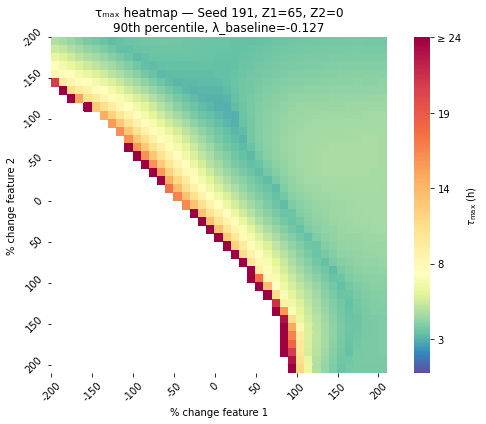

In [16]:


import os


# generator_ids = [40, 62, 94]
   
#seed_latent_vectors = [

#        [496, 407, 288], # 40s
#        [366, 265, 27],  # 62
#        [341, 495, 167], # 94

gen_id = 62
point_id = 191
percentile = 90
tau = 24
fig = helperLatent.plot_one_point_heatmap(
    path_dict,
    gen_id=gen_id,
    point_id=point_id,
    percentile=percentile,
    centered_colorscale=True,
    tau_cutoff=tau
)

out_dir = "latent_analysis/output/km-18to2_decay99/plots/final"
os.makedirs(out_dir, exist_ok=True)

fig.savefig(
    f"{out_dir}/HEATMAP_gen{gen_id}_point{point_id}_pct{percentile}.svg",
    bbox_inches="tight"
)

plt.show()  #



In [47]:
root_gen94 = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_3'
path_dict = helperLatent.parse_generators(root_gen94)

res = np.load(path_dict['gen94']['single']['495_three_point_analysis'], allow_pickle=True).item()
baseline = res['posterior_baseline_lambda']
plus     = res['pc_plus']
minus    = res['pc_minus']

# 4 most changing features
f_changes = np.abs(plus - minus)
f_top4_idx = np.argsort(f_changes)[-4:][::-1]
f_top4_idx

array([75, 47, 74, 59])

# sanity check

In [95]:
import numpy as np
import matplotlib.pyplot as plt

import docker.work.latent_analysis.helpers.helpers_latent as helperLatent

   
seed_latent_vectors = [
        [495, 406, 287],  # 40
        [212, 146, 396],  # 62
        [341, 495, 167],  # 94
    ]

root = 'latent_analysis/output/km-18to2_decay99/3_point_analysis/run_6'
path_dict = helperLatent.parse_generators(root)

helperLatent.sanity_check_individual_vs_joint(path_dict, 62, 27)

====== SANITY CHECK: Joint vs Individual ======
Generator 62 with seed point 27
Top2 features: f1=47, f2=85
Baseline λ (grid center)of joint: 0.848755
Baseline λ (for individual pert): 0.848731

lambda_grid[i_plus, i0]:  0.32740204650980537
pc_plus[f1]:  -61.42450294222601
f1 +100%:
  Joint:      -61.426 %
  Individual: -61.425 %

f1 -100%:
  Joint:       74.863 %
  Individual:  74.868 %

f2 +100%:
  Joint:       72.443 %
  Individual:  72.448 %

f2 -100%:
  Joint:      -35.219 %
  Individual: -35.217 %


In [157]:
gen_dict = path_dict["gen94"]
path = gen_dict['single']['94_three_point_analysis']
res = np.load(path, allow_pickle=True).item()

# === Extract values ===
pc_plus  = res["pc_plus"]
pc_minus = res["pc_minus"]
baseline = res["posterior_baseline_lambda"]

lambda_grid = res["lambda_grid"]
f1, f2 = res["top2_features"]

np.linspace(-2, 2, 41)

TypeError: expected str, bytes or os.PathLike object, not collections.defaultdict

In [43]:
res["posterior_baseline_lambda"]
res["lambda_grid"][20,20]

-0.25462281492436006

In [158]:

def sanity_check_unscaled_params(root_3point_analysis, gen_id, sample_id, path_sampeled_unscaled):

    path_dict = helperLatent.parse_generators(root)
    gen_dict = path_dict["gen"+str(gen_id)]
    path = gen_dict['single'][str(sample_id)+'_three_point_analysis']
    res = np.load(path, allow_pickle=True).item()

    # Define the grid and find the index of the center point (0, 0)
    grid_length = np.linspace(-2, 2, 41).shape[0] # Number of points in one dimension
    center_index = int(0.5 * grid_length**2)  # Index of the center in the flattened grid

    # Access the unscaled Jacobian at the center point
    J_unscaled = res['J_unscaled'][center_index]

    # Load the sampled unscaled parameters
    res_samp = np.load(path_sampeled_unscaled)

    # Print the results
    print(res_samp[sample_id])
    print(J_unscaled)
    difference = np.mean(res_samp[sample_id] - J_unscaled)
    print("Average Difference:", difference)
    return J_unscaled

In [183]:
path_sampeled_unscaled = 'latent_analysis/output/km-18to2_decay99/iter94/samples/500_sampled_params_unscaled.npy'
root_3point_analysis = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_4'
seed_latent_vectors = [
        [53, 296, 167],  # gen95
        [341, 495, 167], # gen94
        [93, 270, 137]   # gen92
    ]

J_unscaled = sanity_check_unscaled_params(root_3point_analysis, 92, 93, path_sampeled_unscaled)

[206.16792   30.468405 107.97711  ... -22.699713 104.77111   94.46367 ]
[185.12332   30.003973  99.280556 ... -32.043865 104.87866  113.89226 ]
Average Difference: 0.10123774


In [184]:
gen_id = 92
sample_id = 93

root_3point_analysis = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_4'

path_dict = helperLatent.parse_generators(root)
gen_dict = path_dict["gen"+str(gen_id)]
path = gen_dict['single'][str(sample_id)+'_three_point_analysis']
res = np.load(path, allow_pickle=True).item()
# Define the grid and find the index of the center point (0, 0)
grid_length = np.linspace(-2, 2, 41).shape[0] # Number of points in one dimension
center_index = int(0.5 * grid_length**2)  # Index of the center in the flattened grid

# Access the unscaled Jacobian at the center point
J_scaled = res['J_scaled'][center_index]
scaled_M_posterior = res['scaled_M_posterior'][sample_id]

# Print the results
print('batch_min ', res['batch_min'])
print(J_scaled)
difference = np.mean(scaled_M_posterior - J_scaled)
print("Average Difference:", difference)

batch_min  -637.4873657226562
[-2.8450432 -5.7028084 -4.426525  ... -6.845916  -4.323391  -4.1573334]
Average Difference: -0.0023642324


In [161]:
# Minimum value of generated Kms = exp(-46)
min_km = -18
# Maximum value of generated Kms = exp(1)
max_km = 2

batch_min = res['batch_min']
batch_max = res['batch_max']

def scale_global(x, batch_min, batch_max, min_x, max_x):
    return ((x - batch_min) / (batch_max - batch_min)) * (max_x - min_x) + min_x


In [176]:
# compare batchmins
gen_id = 95
sampleid = 53
gen_dict = path_dict["gen" + str(gen_id)]
path = gen_dict['single'][str(sampleid) + '_three_point_analysis']
res = np.load(path, allow_pickle=True).item()
N_unscaled = np.vstack((res['N_unscaled_plus'], res['N_unscaled_minus']))
N_unscaled.shape
M_unscaled = np.load(f'latent_analysis/output/km-18to2_decay99/iter{gen_id}/samples/500_sampled_params_unscaled.npy')

M_N = np.vstack((N_unscaled, M_unscaled))
      
# Print the results
print('batch_min_real ', np.min(M_N))
print('batch_max_real ', np.max(M_N))

TypeError: expected str, bytes or os.PathLike object, not collections.defaultdict

In [185]:

print('scaled_M_posterior:', scaled_M_posterior)
print('J_scaled ', J_scaled)
#print('J_scaled_global', J_scaled_global)

difference = np.mean(scaled_M_posterior - J_scaled)
print("Average Difference:", difference)

scaled_M_posterior: [-2.5914097 -5.85071   -4.3316956 ... -6.2948933 -4.072955  -4.4384317]
J_scaled  [-2.8450432 -5.7028084 -4.426525  ... -6.845916  -4.323391  -4.1573334]
Average Difference: -0.0023642324


-618.77954

In [132]:
gen_ids = [95, 94, 92]
sample_id = [[53, 296, 167],  # gen95
        [341, 495, 167], # gen94
        [93, 270, 137]   # gen92
    ]

root_3point_analysis = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2'
path_dict = helperLatent.parse_generators(root)

print("what is stored")
for nr, gen_id in enumerate(gen_ids):  # Use enumerate to get index and value
    for sampleid in sample_id[nr]:
        gen_dict = path_dict["gen" + str(gen_id)]
        path = gen_dict['single'][str(sampleid) + '_three_point_analysis']
        res = np.load(path, allow_pickle=True).item()
        # Print the results
        print('batch_min ', res['batch_min'])

print("what is real")
for nr, gen_id in enumerate(gen_ids):  # Use enumerate to get index and value
    for sampleid in sample_id[nr]:
        gen_dict = path_dict["gen" + str(gen_id)]
        path = gen_dict['single'][str(sampleid) + '_three_point_analysis']
        res = np.load(path, allow_pickle=True).item()
        N_unscaled = np.vstack((res['N_unscaled_plus'], res['N_unscaled_minus']))
        N_unscaled.shape
        M_unscaled = np.load(f'latent_analysis/output/km-18to2_decay99/iter{gen_id}/samples/500_sampled_params_unscaled.npy')

        M_N = np.vstack((N_unscaled, M_unscaled))
      
        # Print the results
        print('batch_min_real ', np.min(M_N))


what is stored
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
batch_min  -637.4873657226562
what is real
batch_min_real  -637.48737
batch_min_real  -637.48737
batch_min_real  -637.48737
batch_min_real  -618.77954
batch_min_real  -618.77954
batch_min_real  -618.77954
batch_min_real  -600.1075
batch_min_real  -596.56464
batch_min_real  -596.56464


In [115]:
!find latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2 -maxdepth 3 -type f -name "*three_point_analysis.npy"


latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen94/gen94_seed167_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen94/gen94_seed495_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen94/gen94_seed341_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen92/gen92_seed137_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen92/gen92_seed93_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2/gen92/gen92_seed270_three_point_analysis.npy
latent_analysis/output/km-18to2_decay99/latent_analys

In [146]:
import numpy as np
import docker.work.latent_analysis.helpers.helpers_latent as helperLatent


def recompute_and_validate_scaling(
    gen_ids,
    seeds_per_gen,
    root_3point_analysis,
    sampled_unscaled_template,
    min_km=-18,
    max_km=2,
    tol=1e-6
):
    """
    Full recomputation pipeline:
       - Rebuild M+N
       - Recompute true batch_min, batch_max
       - Rescale M and J with true bounds
       - Compare with stored values
    """

    def scale_global(x, batch_min, batch_max, min_x, max_x):
        return ((x - batch_min) / (batch_max - batch_min)) * (max_x - min_x) + min_x

    print("\n========== RECOMPUTING SCALING & VALIDATING ==========\n")

    path_dict = helperLatent.parse_generators(root_3point_analysis)

    for gen_idx, gen_id in enumerate(gen_ids):
        print(f"\n=== Generator {gen_id} ===")

        # Load stored unscaled prior batch (M)
        M_path = sampled_unscaled_template.format(gen_id=gen_id)
        M_unscaled = np.load(M_path)

        for seed in seeds_per_gen[gen_idx]:

            print(f"\n--- Seed {seed} ---")

            # LOAD STORED RESULT
            res_path = path_dict[f"gen{gen_id}"]["single"][f"{seed}_three_point_analysis"]
            res = np.load(res_path, allow_pickle=True).item()

            # Extract stored info
            stored_batch_min = res["batch_min"]
            stored_batch_max = res["batch_max"]
            stored_scaled_M = res["scaled_M_posterior"][seed]
            stored_J_scaled = res["J_scaled"]

            # Build N_unscaled
            N_unscaled = np.vstack((res["N_unscaled_plus"], res["N_unscaled_minus"]))

            # REBUILD TRUE M+N
            M_N = np.vstack((M_unscaled, N_unscaled))

            # RECOMPUTE TRUE BOUNDS
            batch_min_real = float(np.min(M_N))
            batch_max_real = float(np.max(M_N))

            print(f"Stored batch_min = {stored_batch_min:.6f}")
            print(f"Real   batch_min = {batch_min_real:.6f}")
            print(f"Stored batch_max = {stored_batch_max:.6f}")
            print(f"Real   batch_max = {batch_max_real:.6f}")

            # Compare stored vs real bounds
            if abs(stored_batch_min - batch_min_real) > 1e-5:
                print("❌ ERROR: batch_min mismatch!")
            else:
                print("✅ batch_min OK")

            if abs(stored_batch_max - batch_max_real) > 1e-5:
                print("❌ ERROR: batch_max mismatch!")
            else:
                print("✅ batch_max OK")

            # REBUILD TRUE UN- SCALED BASELINE & J UN-SCALED CENTER
            true_baseline_unscaled = M_unscaled[seed]
            grid_length = 41
            center_idx = (grid_length // 2) * grid_length + (grid_length // 2)
            J_unscaled_center = res["J_unscaled"][center_idx]

            # RESCALE M AND J WITH TRUE BOUNDS
            M_rescaled_real = scale_global(true_baseline_unscaled,
                                           batch_min_real, batch_max_real,
                                           min_km, max_km)

            J_rescaled_real = scale_global(J_unscaled_center,
                                           batch_min_real, batch_max_real,
                                           min_km, max_km)

            # COMPARE TO STORED VALUES
            diff_M = np.max(np.abs(M_rescaled_real - stored_scaled_M))
            diff_J = np.max(np.abs(J_rescaled_real - stored_J_scaled[center_idx]))

            print(f"\nM rescale difference     = {diff_M:.6e}")
            print(f"J(0,0) rescale diff      = {diff_J:.6e}")

            if diff_M < tol and diff_J < tol:
                print("🎉 Scaling is CORRECT for this seed.")
            else:
                print("🔥 SCALING MISMATCH DETECTED for this seed.")

    print("\n========== DONE ==========\n")


In [148]:
gen_ids = [95, 94, 92]
seeds = [
    [53, 296, 167],     # gen95
    [341, 495, 167],    # gen94
    [93, 270, 137]      # gen92
]

root = "latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/3_point_run_percentiles_2"

sampled_unscaled_template = (
    "latent_analysis/output/km-18to2_decay99/iter{gen_id}/samples/500_sampled_params_unscaled.npy"
)

recompute_and_validate_scaling(gen_ids, seeds, root, sampled_unscaled_template)



========== RECOMPUTING SCALING & VALIDATING ==========


=== Generator 95 ===

--- Seed 53 ---
Stored batch_min = -637.487366
Real   batch_min = -637.487366
Stored batch_max = 448.112274
Real   batch_max = 448.112274
✅ batch_min OK
✅ batch_max OK

M rescale difference     = 0.000000e+00
J(0,0) rescale diff      = 0.000000e+00
🎉 Scaling is CORRECT for this seed.

--- Seed 296 ---
Stored batch_min = -637.487366
Real   batch_min = -637.487366
Stored batch_max = 448.112274
Real   batch_max = 448.112274
✅ batch_min OK
✅ batch_max OK

M rescale difference     = 0.000000e+00
J(0,0) rescale diff      = 0.000000e+00
🎉 Scaling is CORRECT for this seed.

--- Seed 167 ---
Stored batch_min = -637.487366
Real   batch_min = -637.487366
Stored batch_max = 448.112274
Real   batch_max = 448.112274
✅ batch_min OK
✅ batch_max OK

M rescale difference     = 0.000000e+00
J(0,0) rescale diff      = 0.000000e+00
🎉 Scaling is CORRECT for this seed.

=== Generator 94 ===

--- Seed 341 ---
Stored batch_min = -6

# Veocity

In [39]:
path = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/single_perturb_sample_53.npy_sampleIdx53_velocity_2.npy'
data = helperLatent.results_loader(path)
data


{'pert_+0.20': {'perturbance': 0.2,
  'unscaled_samples': array([[122.91178 , -26.71491 , 137.63023 , ...,  54.135082, 117.306625,
          -20.040804],
         [119.42782 , -30.243628, 140.29088 , ...,  54.468884, 113.60141 ,
          -17.240019],
         [119.38697 , -31.039131, 138.39197 , ...,  53.6323  , 113.99733 ,
          -16.745934],
         ...,
         [117.42595 , -29.747341, 139.44798 , ...,  53.576855, 113.42921 ,
          -16.538214],
         [118.1945  , -29.77957 , 137.92633 , ...,  55.129665, 113.894455,
          -17.39102 ],
         [121.16948 , -26.935102, 138.3709  , ...,  60.624683, 109.695595,
          -22.261087]], dtype=float32),
  'scaled_samples': array([[-3.991167 , -6.74774  , -3.7200098, ..., -5.2582417, -4.094431 ,
          -6.6247835],
         [-4.055353 , -6.81275  , -3.670992 , ..., -5.2520914, -4.162693 ,
          -6.573184 ],
         [-4.0561047, -6.827405 , -3.7059765, ..., -5.267503 , -4.1553993,
          -6.564081 ],
         ...,

In [ ]:
path = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/single_perturb_sample_53.npy_sampleIdx53_velocity_1.npy'

perturbations = [20, 60, 100]

import pandas as pd

df = pd.DataFrame()


for pert in perturbations:  

    data['pert_+' + str(pert) + '.00']['eigenvalues']

    
    eigenvalues = np.array(data['pert_+' + str(pert) + '.00']['eigenvalues'])
    baseline = np.array(data['pert_+' + str(pert) + '.00']['baseline_lambda'])

    rows.append(pc)


    







Exception: Data must be 1-dimensional

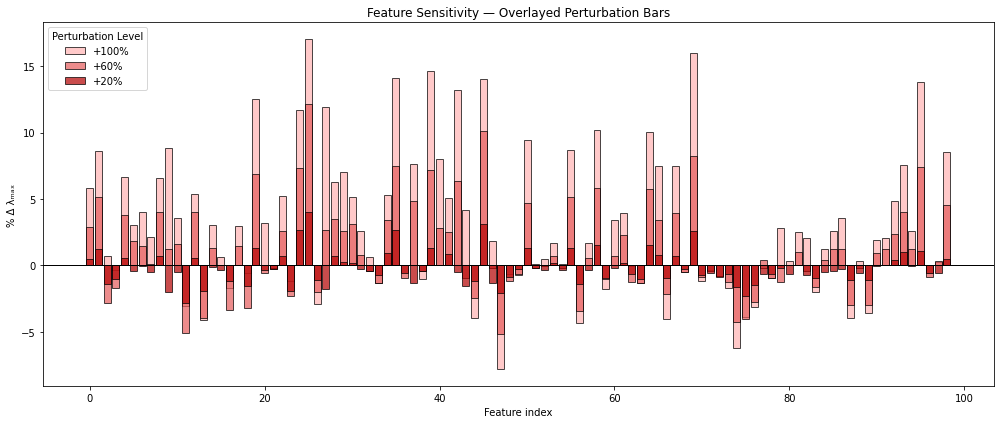

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stacked_perturbations(path, perturbations):
    """
    Makes one stacked bar per feature.
    Each bar shows %Δλmax for +20%, +60%, +100% perturbations.
    """

    # -----------------------------
    # Load dictionary
    # -----------------------------
    data = np.load(path, allow_pickle=True).item()


    # Store percent-change matrices for each perturbation
    PC_list = []      # shape (num_perturbations, num_features)

    for p in perturbations:
        
        key = 'pert_+' + str(p) + '0'

        
        if key not in data:
            print("Missing key:", key)
            continue

        eigs = np.array(data[key]['eigenvalues']).squeeze()
        baseline = np.array(data[key]['baseline_lambda']).squeeze()

        pc = 100 * (eigs - baseline) / np.abs(baseline)
        PC_list.append(pc)

    PC = np.vstack(PC_list)  # Shape: (P, F)
    num_pert = PC.shape[0]
    num_feat = PC.shape[1]

    # -----------------------------
    # Plotting
    # -----------------------------



    x = np.arange(num_feat)
    width = 0.8 / num_pert   # total width = 0.8

    colors = ["#B30000", "#E55C5C", "#FFB3B3"]


    fig, ax = plt.subplots(figsize=(14, 6))

    # Draw largest bars first (so smaller ones appear on top)
    order = np.argsort(-np.array(perturbations))

    for idx in order:
        p = perturbations[idx]
        ax.bar(
            x,
            PC[idx],
            color=colors[idx % len(colors)],
            alpha=0.7,           # transparency so bars behind stay visible
            edgecolor="black",
            label=f"+{int(p*100)}%"
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("Feature index")
    ax.set_ylabel("% Δ λₘₐₓ")
    ax.set_title("Feature Sensitivity — Overlayed Perturbation Bars")
    ax.legend(title="Perturbation Level")

    plt.tight_layout()
    plt.show()
    return PC
path = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/single_perturb_sample_53.npy_sampleIdx53_velocity_2.npy'

PC = plot_stacked_perturbations(path, perturbations=[0.20, 0.60, 1.00])



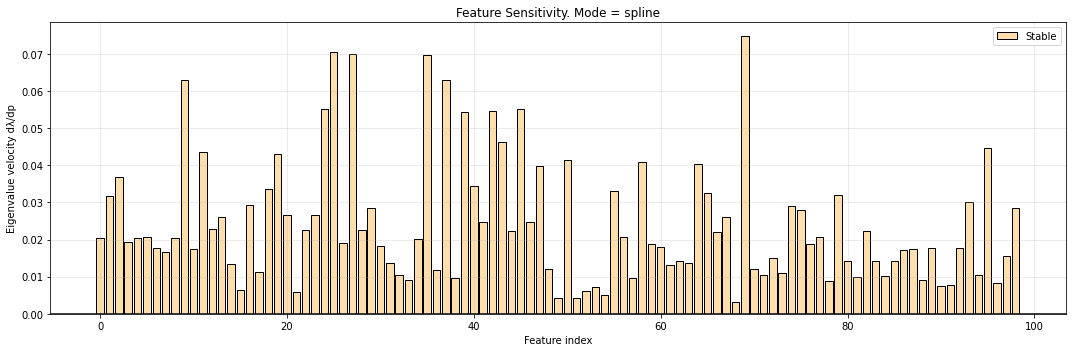


Top sensitive features by eigenvalue sensitivity:
Feature 69: velocity = 0.0747
Feature 25: velocity = 0.0704
Feature 27: velocity = 0.0700
Feature 35: velocity = 0.0698
Feature 37: velocity = 0.0629

Unstable (λ > 0 somewhere): []


In [189]:
import numpy as np
import matplotlib.pyplot as plt

def load_eigen_matrix(path, perturbations):
    data = np.load(path, allow_pickle=True).item()
    eig_list = []

    for p in perturbations:
        key = f"pert_+{p:.2f}"
        if key not in data:
            raise KeyError(f"Missing key: {key}")

        eigs = np.array(data[key]["eigenvalues"]).squeeze()  # shape = (num_features,)
        eig_list.append(eigs)

    return np.vstack(eig_list)   # shape = (num_perturbations, num_features)

def load_eigen_matrix_with_baseline(path, perturbations):
    data = np.load(path, allow_pickle=True).item()

    # take one perturbation to learn how many features exist
    first_key = f"pert_+{perturbations[0]:.2f}"
    example_vec = np.array(data[first_key]["eigenvalues"]).squeeze()
    num_features = example_vec.shape[0]

    # baseline is a scalar
    baseline_scalar = float(np.array(data[first_key]["baseline_lambda"]).squeeze())

    # expand scalar baseline into a vector of length num_features
    baseline_vec = np.full(num_features, baseline_scalar)

    eig_list = [baseline_vec]  # baseline row FIRST

    # Add perturbed eigenvalues
    for p in perturbations:
        key = f"pert_+{p:.2f}"
        if key not in data:
            raise KeyError(f"Missing key: {key}")

        eigs = np.array(data[key]["eigenvalues"]).squeeze()
        eig_list.append(eigs)

    return np.vstack(eig_list)

def compute_curvature(E, p):
    # E: (num_points, num_features)
    # p: array of perturbation values including baseline
    curvature = np.zeros(E.shape[1])

    for j in range(E.shape[1]):
        coeff = np.polyfit(p, E[:, j], 2)  # quadratic
        a = coeff[0]                      # λ = a p^2 + b p + c
        curvature[j] = 2 * abs(a)         # second derivative

    return curvature

from scipy.interpolate import UnivariateSpline

def spline_derivative(E, p, smooth=0.1):
    dv = np.zeros(E.shape[1])
    for j in range(E.shape[1]):
        sp = UnivariateSpline(p, E[:, j], s=smooth)
        dv[j] = np.mean(np.abs(sp.derivative()(p)))
    return dv


def compute_velocities_safe(path, perturbations, mode='abs-differences'):
    data = np.load(path, allow_pickle=True).item()
    E = load_eigen_matrix_with_baseline(path, perturbations)

    # prepend baseline perturbation 0.0
    x = np.array([0.0] + list(perturbations), dtype=float)

    num_feat = E.shape[1]

    velocities = np.full(num_feat, np.nan)
    unstable = np.zeros(num_feat, dtype=bool)

    for j in range(num_feat):
        eigvals = E[:, j]

        # instability rule
        if np.any(eigvals > 0):
            unstable[j] = True
            continue

        if mode == 'linear-fit':
            v, b = np.polyfit(x, eigvals, 1)
            velocities[j] = v

        elif mode == 'abs-differences':
            dy = np.diff(eigvals)
            dx = np.diff(x)  # correct normalization for uneven spacing
            velocities[j] = np.sum(np.abs(dy / dx))

        elif mode == 'curvature':
            curvature = compute_curvature(E, x)
            velocities[j] = curvature[j]

        elif mode == 'spline':
            dv = spline_derivative(E, x, smooth=0.1)
            velocities[j] = dv[j]

    return velocities, unstable


def plot_velocity_barplot_safe(velocities, unstable, mode, color="dodgerblue"):
    plt.figure(figsize=(15, 5))
    x = np.arange(len(velocities))

    # Only stable bars
    plt.bar(x[~unstable], velocities[~unstable],
            color=color, edgecolor="black", label="Stable")

    

    # Mark unstable with red X
    for j in np.where(unstable)[0]:
        plt.plot(j, 0, marker='x', color='red',
                 markersize=12, markeredgewidth=3)

    plt.axhline(0, color="black")
    plt.xlabel("Feature index")
    plt.ylabel("Eigenvalue velocity dλ/dp")
    plt.title('Feature Sensitivity. Mode = ' + mode)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------
# RUN EVERYTHING
# --------------------------------------------------------

path = 'latent_analysis/output/km-18to2_decay99/latent_analysis/individual_feature_perturbance/single_perturb_sample_53.npy_sampleIdx53_velocity_2.npy'
perturbations = [0.20, 0.60, 1.00]
mode = 'spline'#'curvature'  # 'linear-fit' or 'abs-differences'
color = 'navajowhite' # 'plum' #'lightseagreen'
velocities, unstable = compute_velocities_safe(path, perturbations, mode)
plot_velocity_barplot_safe(velocities, unstable, mode, color)

# Sort only stable features
stable_idx = np.where(~unstable)[0]
top5 = stable_idx[np.argsort(np.abs(velocities[stable_idx]))[-5:][::-1]]

print("\nTop sensitive features by eigenvalue sensitivity:")
for idx in top5:
    print(f"Feature {idx}: velocity = {velocities[idx]:.4f}")

print("\nUnstable (λ > 0 somewhere):", np.where(unstable)[0])



In [87]:
PC

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

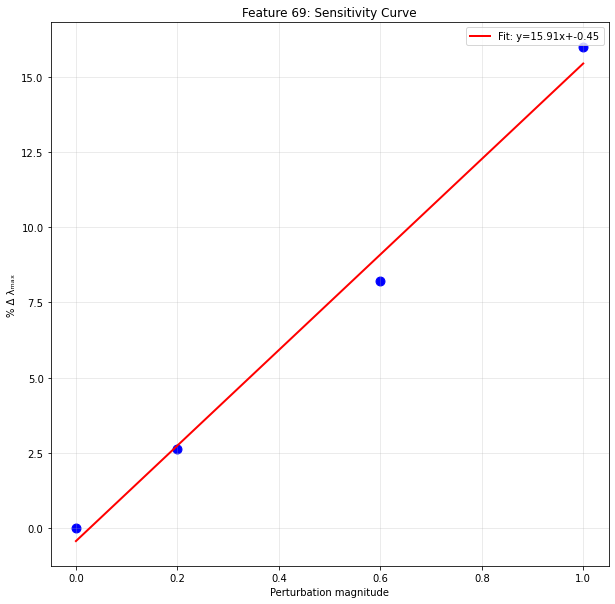

Slope = 15.90735821623819


In [190]:

def get_feature_curve(PC, perturbations, feature_idx):
    x = np.array([0.0] + list(perturbations), dtype=float)
    y = np.array(list(PC[:, feature_idx]), dtype=float)
    return x, y


import numpy as np
import matplotlib.pyplot as plt

def plot_feature_linear_fit(x, y, feature_idx):

    a, b = np.polyfit(x, y, deg=1)
    y_fit = a * x + b

    plt.figure(figsize=(10, 10))
    plt.scatter(x, y, color="blue", s=80)
    plt.plot(x, y_fit, color="red", lw=2, label=f"Fit: y={a:.2f}x+{b:.2f}")

    plt.xlabel("Perturbation magnitude")
    plt.ylabel("% Δ λₘₐₓ")
    plt.title(f"Feature {feature_idx}: Sensitivity Curve")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return a, b


feature_idx = 69   # choose a feature
perturbations = [0.20, 0.60, 1.00]

# PC already computed earlier
x, y = get_feature_curve(PC, perturbations, feature_idx)

# Plot + get slope
slope, intercept = plot_feature_linear_fit(x, y, feature_idx)

print("Slope =", slope)



# Debugging

In [2]:
import helper as hp

import os
import numpy as np
from configparser import ConfigParser
import helper as hp 
import sys
import pandas as pd

import docker.work.latent_analysis.helpers.helpers_latent as helperLatent


# === Load configs ===

# latent specific configs
cfg= ConfigParser()
cfg.read("latent_analysis/latent_config.ini")
latent_cfg = cfg['LATENT_ANALYSIS']

TASK = latent_cfg.getint("task")
perturbations_list = [float(x) for x in latent_cfg.get("perturbations_list").split(",")]

GENERATOR_ID = latent_cfg.getint("generator_id")
SAMPLE_INDEX = latent_cfg.getint("sample_index")
INDEX_FEATURE_1 = latent_cfg.getint("indices_feature_1")
INDEX_FEATURE_2 = latent_cfg.getint("indices_feature_2")

# Paths computed here, not helpers so that we can change them
latent_vectors_path = latent_cfg["latent_vectors_path"] % {
    "generator_id": GENERATOR_ID,
    "n_sets_sampled": latent_cfg.getint("n_sets_sampled")
}
max_eigen_path = latent_cfg["max_eigen_path"] % {
    "generator_id": GENERATOR_ID,
    "n_sets_sampled": latent_cfg.getint("n_sets_sampled")
}
unscaled_batch_path = latent_cfg["unscaled_sampled_parametersets_path"] % {
    "generator_id": GENERATOR_ID,
    "n_sets_sampled": latent_cfg.getint("n_sets_sampled")
}
output_folder_individual = latent_cfg.get("output_folder_individual") % {"generator_id": GENERATOR_ID}
output_file_individual = latent_cfg.get("output_file_individual")

output_folder_heatmap = latent_cfg.get("output_folder_heatmap") % {"generator_id": GENERATOR_ID}
output_file_heatmap = latent_cfg.get("output_file_heatmap") % {
    "generator_id": GENERATOR_ID,
    "indices_feature_1": INDEX_FEATURE_1,
    "indices_feature_2": INDEX_FEATURE_2
}

# Constraints
lnminkm = float(cfg["CONSTRAINTS"]["min_km"])
lnmaxkm = float(cfg["CONSTRAINTS"]["max_km"])

# Parameter names
names_km = hp.load_pkl(cfg["PATHS"]["param_names"])  

# Additional necessary latent_cfgig values
pf_flag = int(cfg["PARAMETER_FIXING"]["pf_flag"])    
n_sets = latent_cfg.getint("n_sets_sampled")               




In [3]:
data = np.load('latent_analysis/output/km-18to2_decay99/iter96/samples/500_sampled_params_unscaled.npy')

data_scaled,_,_ = hp.unscale_range(data, np.min(data), np.max(data),lnminkm, lnmaxkm)
np.save('latent_analysis/output/km-18to2_decay99/iter96/samples/500_sampled_params_scaled.npy', data_scaled)

In [34]:
np.max(data_scaled)

2.0

In [ ]:
# load model

generator_weights_path = 'latent_analysis/output/km-18to2_decay99/training_repeat_0/weights_62.pkl'
mlp, chk_jcbn = helperLatent.load_kinetic_model(
        generator_weights_path=generator_weights_path,
        thermo_file=cfg["PATHS"]["thermo_file"],
        kinetics_file=cfg["PATHS"]["kinetics_file"],
        ss_file=cfg["PATHS"]["ss_file"],
        ss_idx=int(cfg["EVOSTRAT"]["ss_idx"]),
        names_km=names_km,
        lnminkm=lnminkm,
        lnmaxkm=lnmaxkm,
        n_sets=1,
        pf_flag=pf_flag
    )

Loading generator and weights...
99
Loading kinetics and thermodynamics models...


2025-12-10 10:29:36,340 - thermomodel_mini_redYeast8_Date_26Oct2020_151326_Generated_by_redGEMv1 - INFO - # Model initialized with units kcal/mol and temperature 298.15 K


In [5]:
chk_jcbn._prepare_parameters(data_scaled, names_km)
eigenvalues = helperLatent.evaluate_eigenvalues_for_scaled_sets(
    data_scaled,
    chk_jcbn,
    names_km
)
np.save('latent_analysis/output/km-18to2_decay99/iter96/samples/500_sampled_params_max_eig.npy', eigenvalues)

In [18]:
eigs = np.load('latent_analysis/output/km-18to2_decay99/iter62/samples/500_sampled_params_max_eig.npy')

np.savetxt(
    'latent_analysis/output/km-18to2_decay99/iter62/samples/500_sampled_params_max_eig.csv',
    eigs,
    delimiter=','
)


In [12]:
eigenvalues

array([0.70210718])